In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

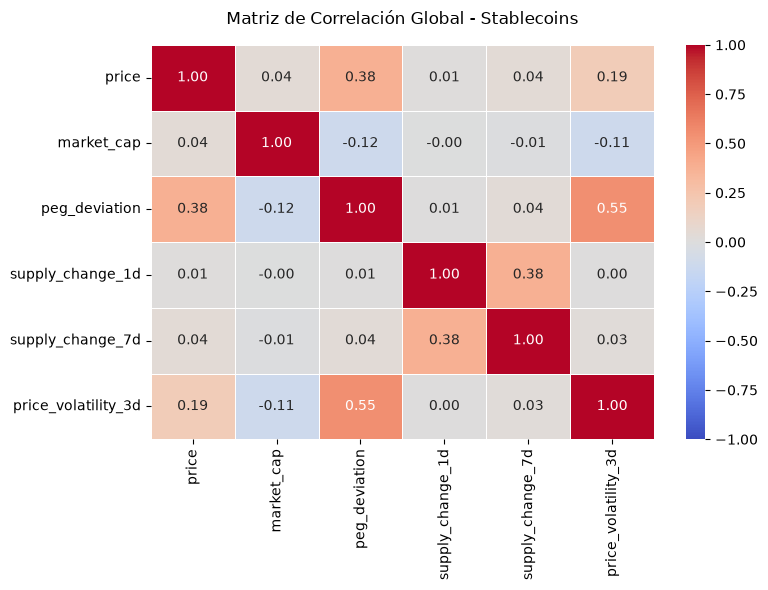

In [3]:
# 1. Panorama General: Heatmap de Correlación

plt.figure(figsize=(8, 6))
# Filtramos solo numéricas
num_cols_stable = ['price', 'market_cap', 'peg_deviation', 'supply_change_1d', 'supply_change_7d', 'price_volatility_3d']
sns.heatmap(df_stable[num_cols_stable].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación Global - Stablecoins', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

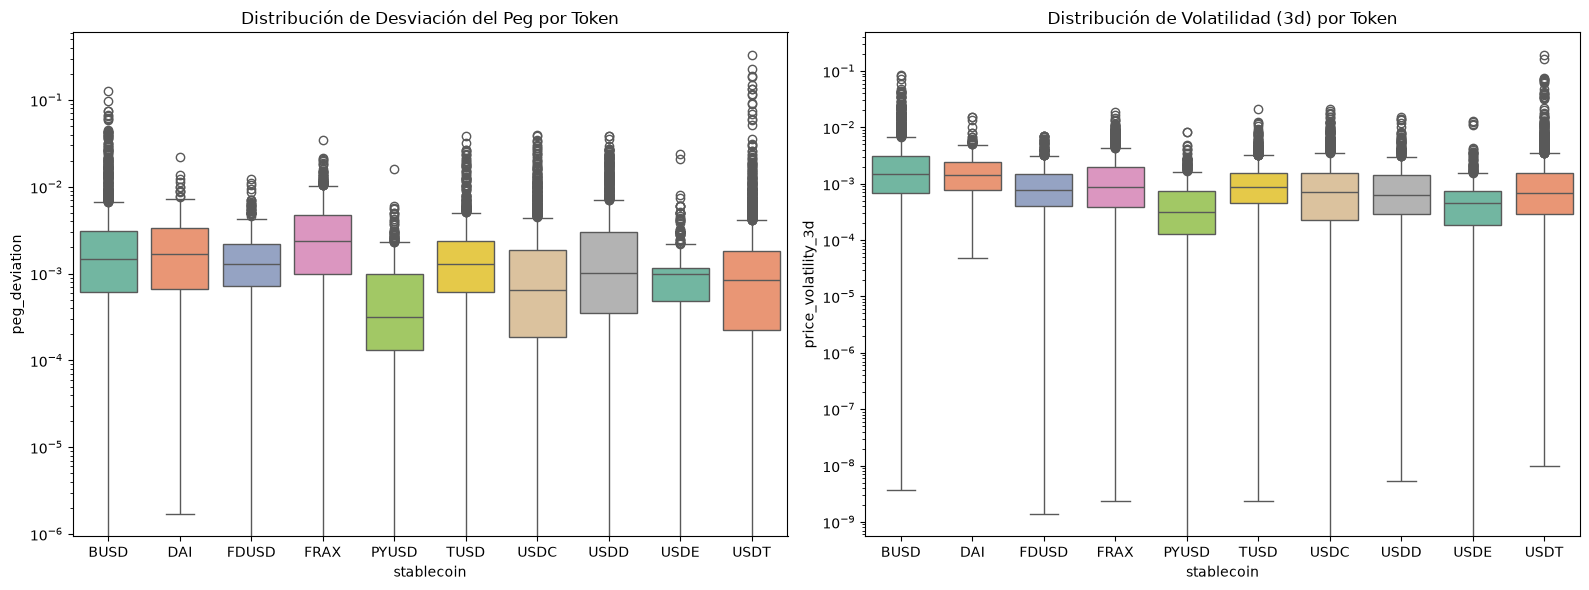

In [4]:
# 2. Categórica vs Numérica: Boxplots por Stablecoin
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Peg Deviation (Escala logarítmica opcional si USDD/FRAX deforman el gráfico)
sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[0], palette='Set2', hue='stablecoin')
axes[0].set_title('Distribución de Desviación del Peg por Token')
axes[0].set_yscale('log') # Usamos escala logarítmica porque las desviaciones suelen ser milimétricas excepto en crisis

# Boxplot Volatilidad a 3 días
sns.boxplot(data=df_stable, x='stablecoin', y='price_volatility_3d', ax=axes[1], palette='Set2', hue='stablecoin')
axes[1].set_title('Distribución de Volatilidad (3d) por Token')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

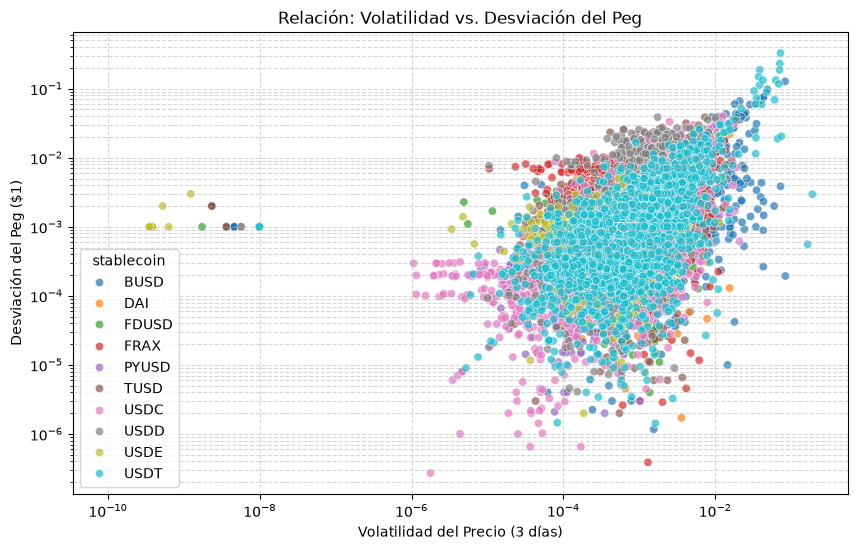

In [5]:
# =========================================================================
# 3. Numérica vs Numérica: Scatter Plot Clave
# =========================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_stable, x='price_volatility_3d', y='peg_deviation', hue='stablecoin', alpha=0.7)
plt.title('Relación: Volatilidad vs. Desviación del Peg')
plt.xlabel('Volatilidad del Precio (3 días)')
plt.ylabel('Desviación del Peg ($1)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

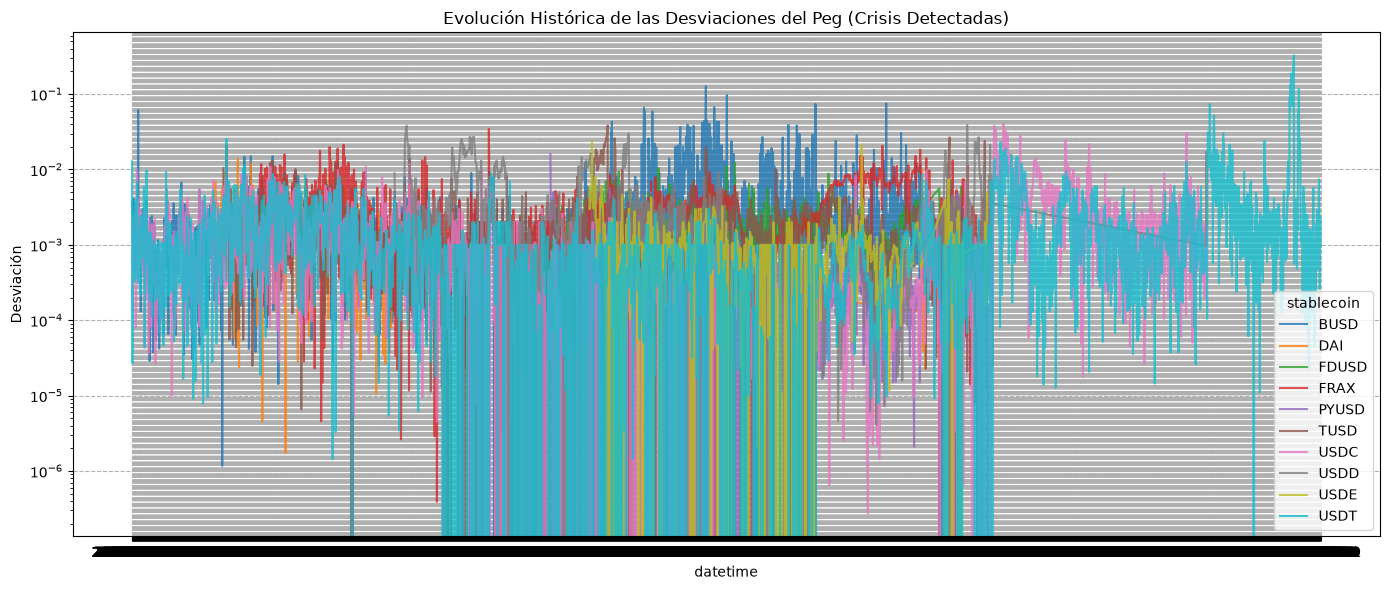

In [6]:
# =========================================================================
# 4. Evolución Temporal Bivariada
# =========================================================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_stable, x='datetime', y='peg_deviation', hue='stablecoin', alpha=0.8)
plt.title('Evolución Histórica de las Desviaciones del Peg (Crisis Detectadas)')
plt.ylabel('Desviación')
plt.yscale('log')
plt.grid(True, ls='--')
plt.tight_layout()
plt.show()

---
# 5. Segmentación por taxonomía y selección de subgrupos

Con 10 stablecoins superpuestas, los gráficos anteriores son difíciles de leer. Aquí las agrupamos usando
una taxonomía cualitativa (nivel de confianza / tipo de respaldo) y las cruzamos con el nº de alertas reales
de `alertas_sistema_final.csv`, para responder dos preguntas distintas con dos subconjuntos distintos:

- **Pregunta A:** ¿Qué monedas son las más inestables según mis propios datos? → Top 5 por nº de alertas (puramente cuantitativo).
- **Pregunta B:** ¿Cómo de distintas son las monedas de riesgo frente a una gigante de referencia? → Top 5 mixto (ancla + las más problemáticas).

In [7]:
# --- Taxonomía cualitativa (nivel de confianza + tipo de respaldo) ---
TAXONOMIA_STABLECOINS = {
    "USDT":  {"nivel": "1_Gigante",   "tipo_respaldo": "Fiat"},
    "USDC":  {"nivel": "1_Gigante",   "tipo_respaldo": "Fiat"},
    "DAI":   {"nivel": "2_Relevante", "tipo_respaldo": "Cripto-colateralizada"},
    "USDE":  {"nivel": "2_Relevante", "tipo_respaldo": "Sintética (delta-neutral)"},
    "PYUSD": {"nivel": "2_Relevante", "tipo_respaldo": "Fiat"},
    "FDUSD": {"nivel": "3_Riesgo",    "tipo_respaldo": "Fiat (liquidez concentrada)"},
    "USDD":  {"nivel": "3_Riesgo",    "tipo_respaldo": "Algorítmica/Cripto"},
    "FRAX":  {"nivel": "3_Riesgo",    "tipo_respaldo": "Fraccionaria-Algorítmica"},
    "TUSD":  {"nivel": "3_Riesgo",    "tipo_respaldo": "Fiat"},
    "BUSD":  {"nivel": "3_Riesgo",    "tipo_respaldo": "Fiat (descontinuada)"},
}
ORDEN_NIVELES = ["1_Gigante", "2_Relevante", "3_Riesgo"]

df_tax = pd.DataFrame.from_dict(TAXONOMIA_STABLECOINS, orient="index")
df_stable = df_stable.merge(df_tax, left_on="stablecoin", right_index=True, how="left")

# --- Nº de alertas reales por stablecoin (criterio cuantitativo) ---
df_alertas = pd.read_csv("../data/clean/alertas_sistema_final.csv")
n_alertas = (
    df_alertas[df_alertas["nivel_alerta"] != "0_normal"]
    .groupby("stablecoin")["nivel_alerta"].count()
    .rename("n_alertas")
)

df_criterio = df_tax.join(n_alertas).fillna({"n_alertas": 0})
df_criterio["n_alertas"] = df_criterio["n_alertas"].astype(int)
df_criterio.sort_values("n_alertas", ascending=False)

,nivel,tipo_respaldo,n_alertas
BUSD,3_Riesgo,Fiat (descontinuada),58
USDE,2_Relevante,Sintética (delta-neutral),22
FDUSD,3_Riesgo,Fiat (liquidez concentrada),19
USDD,3_Riesgo,Algorítmica/Cripto,15
PYUSD,2_Relevante,Fiat,14
TUSD,3_Riesgo,Fiat,11
FRAX,3_Riesgo,Fraccionaria-Algorítmica,8
USDC,1_Gigante,Fiat,1
USDT,1_Gigante,Fiat,0
DAI,2_Relevante,Cripto-colateralizada,0


In [8]:
# --- Selección de subgrupos ---

# Pregunta A: top 5 solo por nº de alertas (las que MÁS dan guerra en la práctica)
top5_A = df_criterio.sort_values("n_alertas", ascending=False).head(5).index.tolist()

# Pregunta B: ancla del Nivel 1 (USDT) + Nivel 2 relevante (USDE) + las 3 más problemáticas del Nivel 3
top5_B = (
    ["USDT", "USDE"] +
    df_criterio.loc[df_criterio["nivel"] == "3_Riesgo"]
               .sort_values("n_alertas", ascending=False).head(3).index.tolist()
)

print("Top 5 — Pregunta A (más inestables):", top5_A)
print("Top 5 — Pregunta B (riesgo vs. ancla):", top5_B)

Top 5 — Pregunta A (más inestables): ['BUSD', 'USDE', 'FDUSD', 'USDD', 'PYUSD']
Top 5 — Pregunta B (riesgo vs. ancla): ['USDT', 'USDE', 'BUSD', 'FDUSD', 'USDD']


--- ESTO ES LO NUEVO QUE AÑADÍ ---

## Pregunta A — ¿Qué monedas son las más inestables según mis propios datos?

Filtramos a las 5 con más alertas históricas y comparamos su `peg_deviation` y volatilidad entre sí.

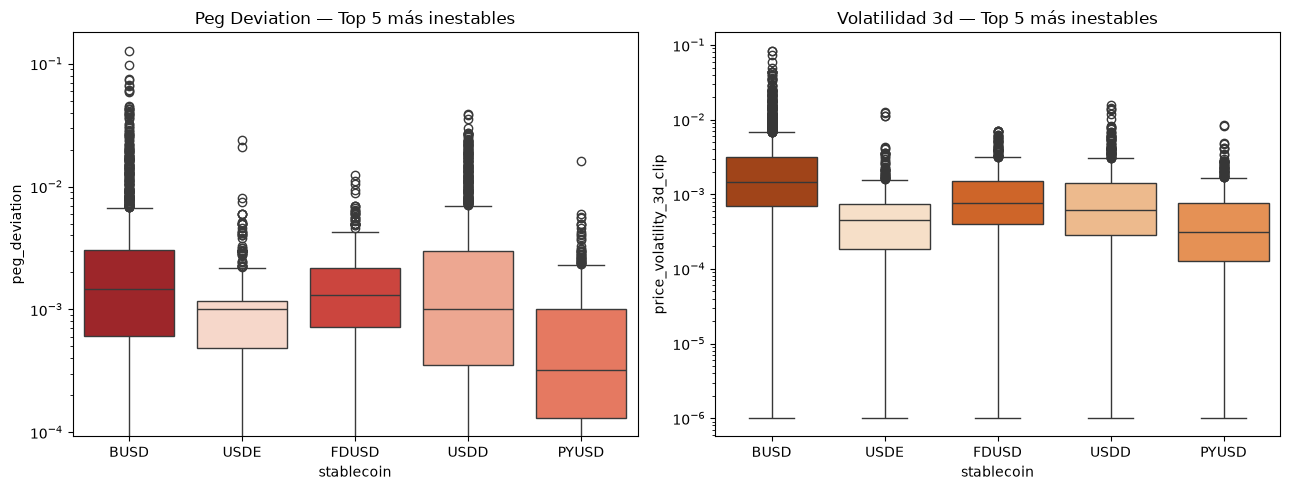

,peg_deviation,price_volatility_3d
stablecoin,,
BUSD,0.001460,0.001478
USDE,0.001000,0.000459
FDUSD,0.001305,0.000765
USDD,0.001011,0.000620
PYUSD,0.000320,0.000311


In [11]:
df_A = df_stable[df_stable["stablecoin"].isin(top5_A)].copy()
df_A["price_volatility_3d_clip"] = df_A["price_volatility_3d"].clip(lower=1e-6)  # evita el piso de ruido flotante en 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_A, x="stablecoin", y="peg_deviation", order=top5_A,
            hue="stablecoin", palette="Reds_r", legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Peg Deviation — Top 5 más inestables")

sns.boxplot(data=df_A, x="stablecoin", y="price_volatility_3d_clip", order=top5_A,
            hue="stablecoin", palette="Oranges_r", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Volatilidad 3d — Top 5 más inestables")
plt.tight_layout()
plt.show()

df_A.groupby("stablecoin")[["peg_deviation", "price_volatility_3d"]].median().reindex(top5_A)


#### Izquierda: Peg Deviation (Desviación de la Paridad)

Este gráfico mide qué tanto se alejó el precio de la stablecoin de su valor teórico de $1 USD.

 - BUSD: Es la que muestra una mediana de desviación más alta (cerca de $1.5 \times 10^{-3}$ o 0.15%) y posee una cantidad masiva de outliers que llegan a superar el 10% de desviación ($10^{-1}$). Esto indica que experimentó despegues (depegs) severos y frecuentes.
        
- USDD y FDUSD: También muestran una dispersión alta en sus cajas, lo que significa que de manera cotidiana son menos exactas manteniendo el $1 USD. USDD tiene además picos de depeg muy altos (casi 4%).
        
- PYUSD: Tiene la mediana más baja de desviación, manteniéndose generalmente más cerca del $1 USD, aunque tiene algunos eventos aislados de desparidad.

#### Derecha: Volatilidad a 3 días (Volatility 3d)

Este gráfico mide la intensidad y rapidez de los cambios de precio en ventanas de 3 días.

- BUSD: Vuelve a destacar negativamente. Su caja está notablemente más alta que las demás, lo que significa que es consistentemente la más volátil en el corto plazo, además de acumular la mayor densidad de picos de volatilidad extrema ($10^{-1}$).

- FDUSD y USDD: Tienen un comportamiento de volatilidad intermedia bastante similar entre sí, con medianas parecidas, pero FDUSD muestra un rango de bigotes más concentrado en la parte baja.

- USDE: Muestra una volatilidad cotidiana más baja (su caja está más abajo), pero llama la atención que tiene outliers muy marcados que rompen su comportamiento normal.
        

Comparamos"los peores contra los peores" nos es útil para rankear riesgo interno del grupo problemático, pero no te dice si ese riesgo es alto en términos absolutos.

## Pregunta B — ¿Cómo de distintas son las de riesgo frente a una gigante de referencia?

Aquí dejamos `USDT` como ancla de comparación (Nivel 1) junto a `USDE` (Nivel 2) y las 3 más problemáticas
del Nivel 3. El color por `nivel` deja ver de un vistazo si la distancia entre grupos es grande o no.

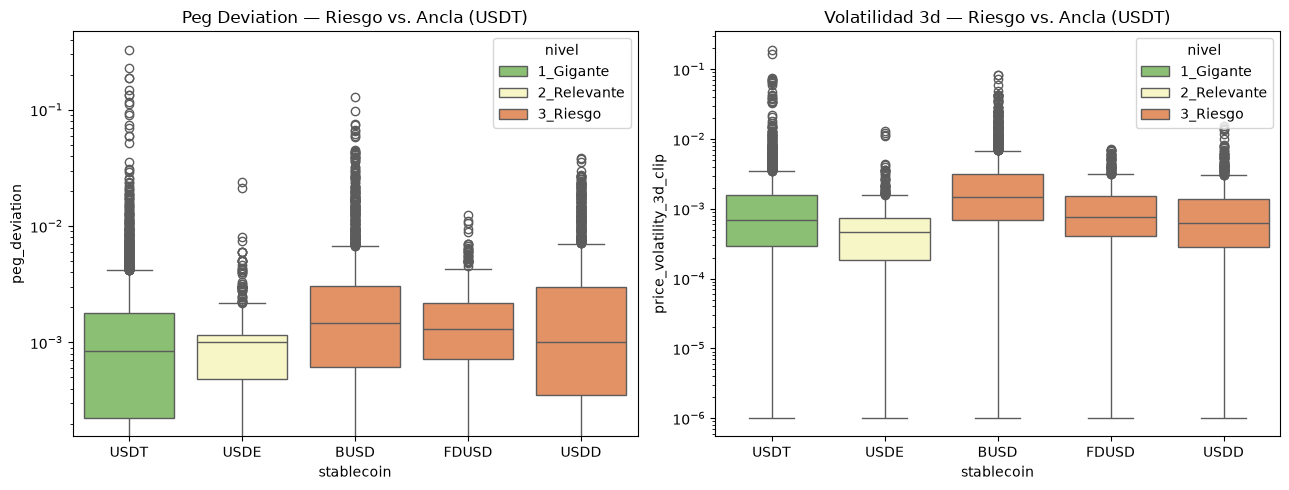

,peg_deviation,price_volatility_3d
stablecoin,,
USDT,0.000834,0.000688
USDE,0.001000,0.000459
BUSD,0.001460,0.001478
FDUSD,0.001305,0.000765
USDD,0.001011,0.000620


In [10]:
df_B = df_stable[df_stable["stablecoin"].isin(top5_B)].copy()
df_B["price_volatility_3d_clip"] = df_B["price_volatility_3d"].clip(lower=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df_B, x="stablecoin", y="peg_deviation", order=top5_B,
            hue="nivel", hue_order=ORDEN_NIVELES, dodge=False, palette="RdYlGn_r", ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Peg Deviation — Riesgo vs. Ancla (USDT)")

sns.boxplot(data=df_B, x="stablecoin", y="price_volatility_3d_clip", order=top5_B,
            hue="nivel", hue_order=ORDEN_NIVELES, dodge=False, palette="RdYlGn_r", ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Volatilidad 3d — Riesgo vs. Ancla (USDT)")
plt.tight_layout()
plt.show()

df_B.groupby("stablecoin")[["peg_deviation", "price_volatility_3d"]].median().reindex(top5_B)

La caja de `USDT` es nuestra vara de medir: cuanto más se alejan las demás cajas de la suya (en mediana y en longitud de bigotes/outliers), más fuerte es la evidencia de que esas monedas son realmente más inestables y no solo "ruido normal" del mercado.

## Pregunta C — ¿El tipo de respaldo importa más que el nivel de confianza?

Comparamos `peg_deviation` y volatilidad agrupando por `tipo_respaldo` en vez de por `nivel`,
para ver si el verdadero factor de riesgo es el mecanismo (fiat/algorítmico/sintético/cripto-colateralizado)
más que el tamaño o la reputación de la moneda.

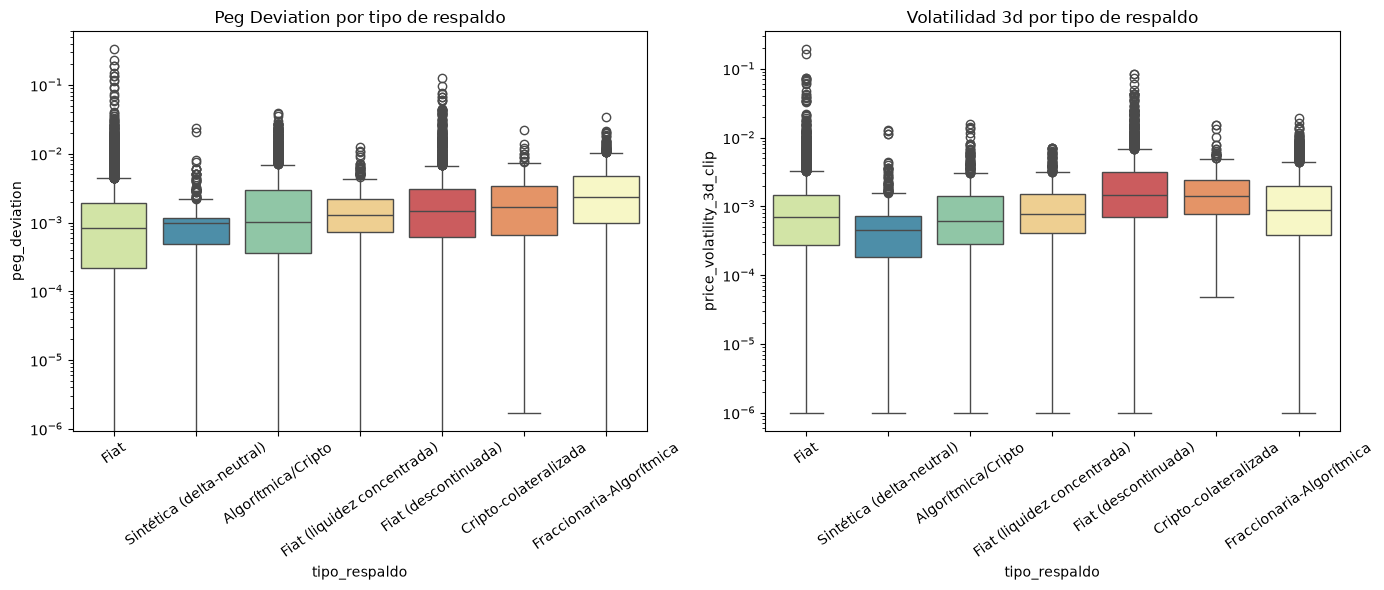

In [12]:
# Orden por mediana de peg_deviation (de más estable a menos estable)
orden_respaldo = (
    df_stable.groupby("tipo_respaldo")["peg_deviation"]
    .median()
    .sort_values()
    .index.tolist()
)

df_stable["price_volatility_3d_clip"] = df_stable["price_volatility_3d"].clip(lower=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(data=df_stable, x="tipo_respaldo", y="peg_deviation", order=orden_respaldo,
            hue="tipo_respaldo", palette="Spectral", legend=False, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Peg Deviation por tipo de respaldo")
axes[0].tick_params(axis="x", rotation=35)

sns.boxplot(data=df_stable, x="tipo_respaldo", y="price_volatility_3d_clip", order=orden_respaldo,
            hue="tipo_respaldo", palette="Spectral", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Volatilidad 3d por tipo de respaldo")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

In [13]:
# Comparamos la dispersión de medianas dentro de cada agrupación:
# si un criterio "explica" mejor el riesgo, sus grupos deberían diferenciarse más entre sí.

resumen_nivel = df_stable.groupby("nivel")["peg_deviation"].median()
resumen_respaldo = df_stable.groupby("tipo_respaldo")["peg_deviation"].median()

print("Dispersión de medianas por NIVEL (min, max, rango):")
print(resumen_nivel.min(), resumen_nivel.max(), resumen_nivel.max() - resumen_nivel.min())
print(resumen_nivel.sort_values(ascending=False))

print("\nDispersión de medianas por TIPO DE RESPALDO (min, max, rango):")
print(resumen_respaldo.min(), resumen_respaldo.max(), resumen_respaldo.max() - resumen_respaldo.min())
print(resumen_respaldo.sort_values(ascending=False))

Dispersión de medianas por NIVEL (min, max, rango):
0.0007529211720974 0.0014877831718783 0.0007348619997809
nivel
3_Riesgo       0.001488
2_Relevante    0.000827
1_Gigante      0.000753
Name: peg_deviation, dtype: float64

Dispersión de medianas por TIPO DE RESPALDO (min, max, rango):
0.00084014620463385 0.0023620898213677 0.00152194361673385
tipo_respaldo
Fraccionaria-Algorítmica       0.002362
Cripto-colateralizada          0.001663
Fiat (descontinuada)           0.001460
Fiat (liquidez concentrada)    0.001305
Algorítmica/Cripto             0.001011
Sintética (delta-neutral)      0.001000
Fiat                           0.000840
Name: peg_deviation, dtype: float64
